# Два индекса Джини и их связь с ROC-AUC

В ML слово “Gini” встречается в двух разных смыслах, и их часто путают:

1) **Gini coefficient** (метрика качества ранжирования модели)  
   Обычно в скоринге/бинарной классификации, связан с ROC-AUC:
$$
\text{Gini} = 2 \cdot \text{AUC} - 1
$$


2) **Gini impurity** (критерий "нечистоты" узла в деревьях решений)  
   Используется для выбора лучшего разбиения внутри дерева:
$$
   G = 1 - \sum_k p_k^2
$$

Дальше: сначала быстро вспомним ROC-AUC (без него не понять первый Gini), затем разберём оба Gini по отдельности.

> Замечание: связь `Gini = 2*AUC-1` — это про **бинарную классификацию** (качество ранжирования).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

np.random.seed(42)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

# Compatibility helpers for full notebook execution.
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

def check_close(value, expected, tol=1e-12, name="value"):
    assert abs(value - expected) <= tol, f"{name}: {value} != {expected}"


# Истоки понятия. Экономический смысл
Коэффициент Джини — это статистический показатель **степени расслоения общества относительно какого-либо экономического признака** (годовой доход, имущество, недвижимость).


Коэффициент показывает **отклонение фактического распределения доходов в обществе от абсолютно равного их распределения между населением** и позволяет очень точно оценить неравномерность распределения доходов в обществе.

Ранее Макс Лоренц предложил способ измерения концентрации благосостояния общества, получивший позже название «Кривая Лоренца». Далее мы покажем, что **Коэффициент Джини является абсолютно точной алгебраической интерпретацией Кривой Лоренца, а она в свою очередь является его графическим отображением.**

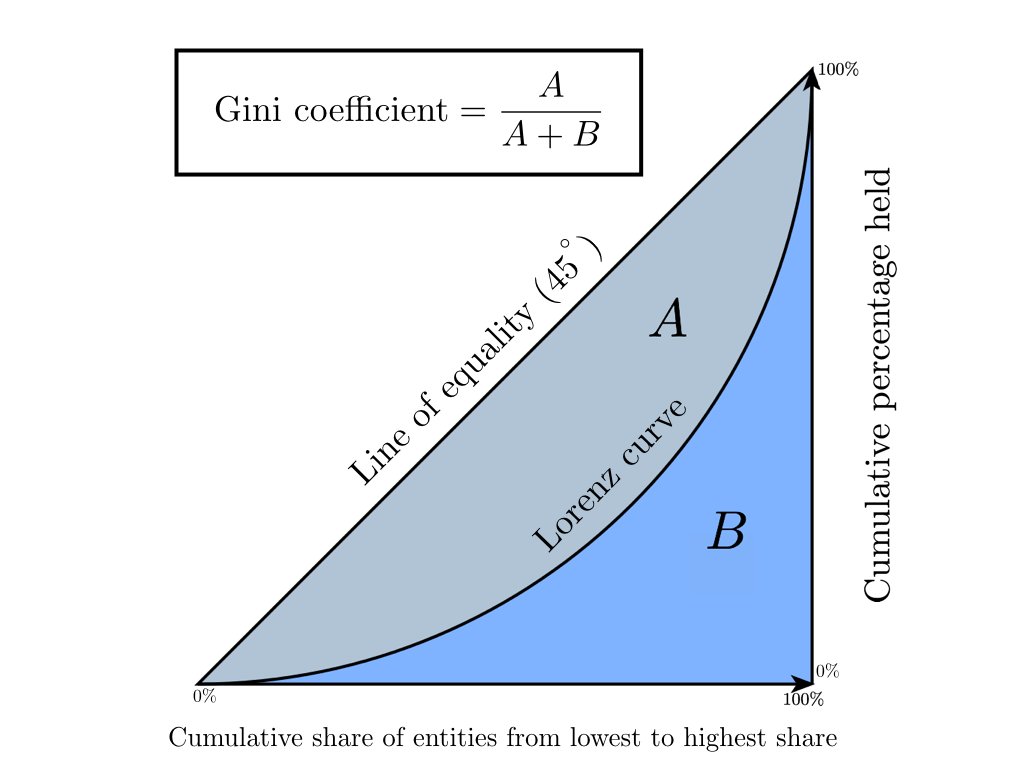

# Расчет коэфициента Джини на примере
В экономике существует несколько способов рассчитать этот коэффициент, мы остановимся на формуле Брауна (предварительно необходимо создать вариационный ряд — отранжировать население по доходам):

$G = 1 - \sum_{k=1}^n(X_k - X_{k-1})(Y_k + Y_{k-1})$


где $n$ — число жителей, $X_k$ — кумулятивная доля населения, $Y_k$ — кумулятивная доля дохода для $X_k$


Предположим, есть три деревни, в каждой из которых проживает 10 жителей. В каждой деревне суммарный годовой доход населения 100 рублей.


1. Первая деревня - все жители зарабатывают одинаково — 10 рублей в год   
2. Вторая деревня - 3 человека зарабатывают по 5 рублей, 4 человека — по 10 рублей и 3 человека по 15 рублей.
3. Третья деревня -  7 человек получают 1 рубль в год, 1 человек — 10 рублей, 1 человек — 33 рубля и один человек — 50 рублей.

Для каждой деревни рассчитаем коэффициент Джини и построим кривую Лоренца.

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

village = pd.DataFrame({'Person':['Person_{}'.format(i) for i in range(1,11)],
                        'Income_Village_1':[10]*10,
                        'Income_Village_2':[5,5,5,10,10,10,10,15,15,15],
                        'Income_Village_3':[1,1,1,1,1,1,1,10,33,50]})
village['Cum_population'] =  np.cumsum(np.ones(10)/10)
village['Cum_Income_Village_1'] =  np.cumsum(village['Income_Village_1']/100)
village['Cum_Income_Village_2'] =  np.cumsum(village['Income_Village_2']/100)
village['Cum_Income_Village_3'] =  np.cumsum(village['Income_Village_3']/100)
village = village.iloc[:, [3,4,0,5,1,6,2,7]]
village

In [ ]:
plt.figure(figsize = (8,8))
Gini=[]

for i in range(1,4):
    X_k = village['Cum_population'].values
    X_k_1 = village['Cum_population'].shift().fillna(0).values
    Y_k = village['Cum_Income_Village_{}'.format(i)].values
    Y_k_1 = village['Cum_Income_Village_{}'.format(i)].shift().fillna(0).values
    Gini.append(1 - np.sum((X_k - X_k_1) * (Y_k + Y_k_1)))
    plt.plot(np.insert(X_k,0,0), np.insert(village['Cum_Income_Village_{}'.format(i)].values,0,0),
             label='Деревня {} (Gini = {:0.2f})'.format(i, Gini[i-1]))

plt.title('Коэффициент Джини')
plt.xlabel('Кумулятивная доля населения')
plt.ylabel('Кумулятивная доля дохода')
plt.legend(loc="upper left")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

**Чем больше расслоение среди населения относительно годового дохода, тем больше площадь фигуры, образуемой кривой Лоренца и диагональю.**


 Покажем на примере третьей деревни, что отношение площади этой фигуры к площади треугольника, образуемого линией абсолютного равенства, в точности равна значению коэффициента Джини:


In [ ]:
curve_area = np.trapz(np.insert(village['Cum_Income_Village_3'].values,0,0), np.insert(village['Cum_population'].values,0,0))
S = (0.5 - curve_area) / 0.5

plt.figure(figsize = (8,8))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')
plt.plot(np.insert(village['Cum_population'].values,0,0), np.insert(village['Cum_Income_Village_3'].values,0,0),
             label='Деревня {} (Gini = {:0.2f})'.format(i, Gini[i-1]),lw = 2,color = 'green')

plt.fill_between(np.insert(X_k,0,0), np.insert(X_k,0,0), y2=np.insert(village['Cum_Income_Village_3'].values,0,0), alpha=0.5)
plt.text(0.45,0.27,'S = {:0.2f}'.format(S),fontsize = 28)
plt.title('Коэффициент Джини')
plt.xlabel('Кумулятивная доля населения')
plt.ylabel('Кумулятивная доля дохода')
plt.legend(loc="upper left")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

Давайте остановимся на ещё одном важном моменте: рассчитывая коэффициент Джини, мы никак не классифицируем людей на бедных и богатых, он никак не зависит от того, кого мы сочтем нищим или олигархом. Но предположим, что перед нами встала такая задача, для этого в зависимости от того, что мы хотим получить, какие у нас цели, нам необходимо будет задать порог дохода четко разделяющий людей на бедных и богатых. Эта задача похожа на задачу  с Threshold (оптимальный порог вероятности) из задач бинарной классификации Машинного обучения.

## В машинном обучении
Предположим, мы решаем задачу бинарной классификации для 15 объектов и у нас следующее распределение классов:

$[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]$

Наш обученный алгоритм предсказывает следующие вероятности отношения к классу «1» на этих объектах:
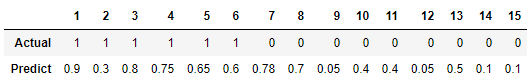

Рассчитаем коэффициент Джини для двух моделей: наш обученный алгоритм и идеальная модель, точно предсказывающая классы с вероятностью 100%.

Идея следующая: **вместо ранжирования населения по уровню дохода, мы ранжируем предсказанные вероятности модели по убыванию и подставляем в формулу кумулятивную долю истинных значений целевой переменной, соответствующих предсказанным вероятностям.** Иными словами, сортируем таблицу по строке «Predict» и считаем кумулятивную долю классов вместо кумулятивной доли доходов.

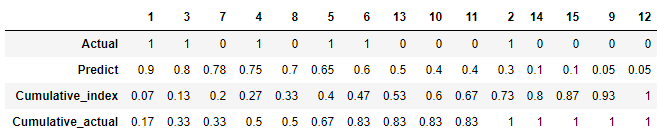

In [ ]:
from scipy.interpolate import interp1d
from scipy.integrate import quad

actual = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
predict = [0.9, 0.3, 0.8, 0.75, 0.65, 0.6, 0.78, 0.7, 0.05, 0.4, 0.4, 0.05, 0.5, 0.1, 0.1]

data = zip(actual, predict)
sorted_data = sorted(data, key=lambda d: d[1], reverse=True)
sorted_actual = [d[0] for d in sorted_data]

cumulative_actual = np.cumsum(sorted_actual) / sum(actual)
cumulative_index = np.arange(1, len(cumulative_actual)+1) / len(predict)
cumulative_actual_perfect = np.cumsum(sorted(actual, reverse=True)) / sum(actual)

x_values = [0] + list(cumulative_index)
y_values = [0] + list(cumulative_actual)
y_values_perfect = [0] + list(cumulative_actual_perfect)

f1, f2 = interp1d(x_values, y_values), interp1d(x_values, y_values_perfect)
S_pred = quad(f1, 0, 1, points=x_values)[0] - 0.5
S_actual = quad(f2, 0, 1, points=x_values)[0] - 0.5

fig, ax = plt.subplots(nrows=1,ncols=2, sharey=True, figsize=(14, 7))
ax[0].plot(x_values, y_values, lw = 2, color = 'blue', marker='x')
ax[0].fill_between(x_values, x_values, y_values, color = 'blue', alpha=0.1)
ax[0].text(0.4,0.2,'S = {:0.4f}'.format(S_pred),fontsize = 28)
ax[1].plot(x_values, y_values_perfect, lw = 2, color = 'green', marker='x')
ax[1].fill_between(x_values, x_values, y_values_perfect, color = 'green', alpha=0.1)
ax[1].text(0.4,0.2,'S = {:0.4f}'.format(S_actual),fontsize = 28)

for i in range(2):
    ax[i].plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')
    ax[i].set(title='Коэффициент Джини', xlabel='Кумулятивная доля объектов',
              ylabel='Кумулятивная доля истинных классов', xlim=(0, 1), ylim=(0, 1))
plt.show();


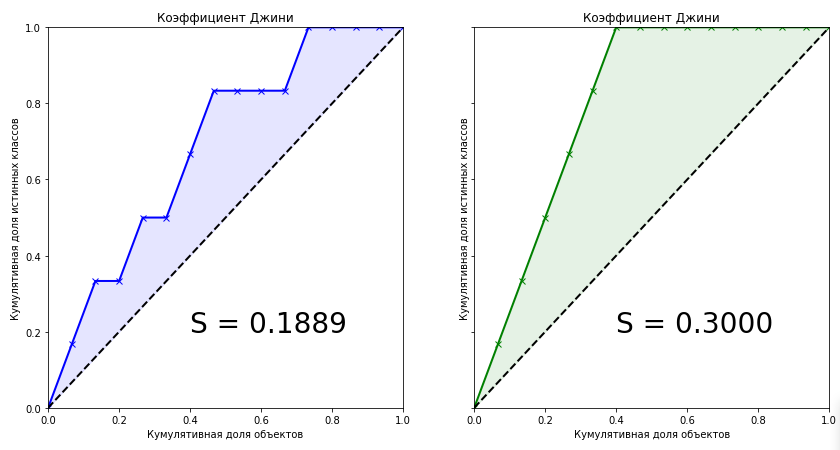

## Напоминание: ROC-AUC


Часто результат работы алгоритма на фиксированной тестовой выборке визуализируют с помощью ROC-кривой (ROC = receiver operating characteristic, иногда говорят «кривая ошибок»), а качество оценивают как площадь под этой кривой – AUC (AUC = area under the curve).

ROC-кривая показывает компромисс между:
- **TPR** (True Positive Rate) — доля найденных положительных
- **FPR** (False Positive Rate) — доля ложных срабатываний

**AUC** — площадь под ROC-кривой.

Интерпретация:
$$
\text{AUC} = \mathbb{P}(s(x^+) > s(x^-))
$$
То есть вероятность, что случайный positive получит score выше, чем случайный negative.


Идеальному соответствует ROC-кривая, проходящая через точку (0, 1), площадь под ней равна 1. Наихудшему – ROC-кривая, проходящая через точку (1, 0), площадь под ней – 0. Случайному – что-то похожее на диагональ квадрата, площадь примерно равна 0.5.

In [ ]:
# Генерируем бинарную задачу и "скоры" модели
n = 2000
y_true = np.random.binomial(1, 0.3, n)

# score: положительным даём небольшой сдвиг вверх + шум
y_score = 0.8 * y_true + np.random.normal(0, 0.6, n)

# нормируем в [0, 1] (не обязательно, но удобно для объяснения)
y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Геометрическая связь Gini coefficient и ROC-AUC

На ROC-графике:

- Площадь под ROC-кривой = **AUC**
- Площадь под диагональю (случайная модель) = **0.5**

Обозначим выигрыш модели над случайной:

$$
\Delta = \text{AUC} - 0.5
$$

Тогда:

$$
\text{Gini} = 2\cdot \text{AUC} - 1
           = 2(\text{AUC} - 0.5)
           = 2\Delta
$$

То есть **Gini — это удвоенная площадь между ROC-кривой и диагональю**.


In [ ]:
from numpy import trapz

# ROC
auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

# численно считаем площадь под ROC
auc_numeric = trapz(tpr, fpr)

# площадь между ROC и диагональю (выигрыш)
delta_area = auc_numeric - 0.5

# gini двумя способами
gini_formula = 2 * auc_numeric - 1
gini_area = 2 * delta_area

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_numeric:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")

# штриховка "выигрыша": между tpr и диагональю y=x
plt.fill_between(fpr, tpr, fpr, alpha=0.25, label=r"Area = AUC - 0.5")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("AUC and the 'advantage area' over random")
plt.legend()
plt.show()

print(f"AUC (trapz): {auc_numeric:.6f}")
print(f"Delta area (AUC - 0.5): {delta_area:.6f}")
print(f"Gini (2*AUC - 1): {gini_formula:.6f}")
print(f"Gini (2*(AUC-0.5)): {gini_area:.6f}")


In [ ]:
def plot_roc(scores, label):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_val = roc_auc_score(y_true, scores)
    plt.plot(fpr, tpr, label=f"{label}: AUC={auc_val:.3f}, Gini={2*auc_val-1:.3f}")

random_scores = np.random.rand(n)
good_scores = y_score
bad_scores = 1 - y_score

plt.figure()
plot_roc(random_scores, "Random")
plot_roc(good_scores, "Good")
plot_roc(bad_scores, "Inverted")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-AUC and Gini coefficient: three scenarios")
plt.legend()
plt.show()


## Нормализованный коэффициент Джини

Если модель даёт некоторый Gini, возникает вопрос:

Много это или мало?

Без знания точного значения коэффициента для идеального алгоритма мы не можем сказать о нашей модели ничего. Поэтому метрикой качества в машинном обучении является нормализованный коэффициент Джини, который равен отношению коэффициента обученной модели к коэффициенту идеальной модели.

Чтобы корректно оценить модель,
используют нормализованный коэффициент Джини:

$$
Gini_{normalized} =
\frac{Gini_{model}}{Gini_{perfect}}
$$

Где:
- $Gini_{model}$ — коэффициент для нашей модели
- $Gini_{perfect}$ — коэффициент для идеального ранжирования

Для бинарной классификации:

$$
Gini_{perfect} = 1
$$

Поэтому часто нормализация неявно скрыта в формуле:

$$
Gini = 2 \cdot AUC - 1
$$


In [ ]:
# Gini для модели
gini_model = 2 * auc - 1

# Gini для идеального ранжирования
gini_perfect = 2 * 1.0 - 1  # AUC идеальной модели = 1

gini_normalized = gini_model / gini_perfect

print("Gini model:", gini_model)
print("Gini normalized:", gini_normalized)

## Практическое применение коэффициента Джини

Коэффициент Джини (в форме $Gini = 2 \cdot AUC - 1$) широко используется
в задачах бинарной классификации, где важна **способность модели ранжировать объекты по риску или вероятности события**.

### 1. Кредитный скоринг

Банки оценивают вероятность дефолта клиента.

- Модель строит score — вероятность невозврата кредита.
- Клиенты сортируются по риску.
- Gini показывает, насколько хорошо модель отделяет "плохих" клиентов от "хороших".

Чем выше Gini — тем лучше модель различает рискованные и надёжные заявки.

Используется для:
- сравнения моделей,
- мониторинга деградации модели,
- выбора лучшей версии скоринговой системы.

---

### 2. Страхование

Задача — предсказать вероятность страхового случая (claim).

- Клиенты ранжируются по вероятности обращения.
- Gini показывает качество разделения "будет claim" / "не будет claim".
- Часто используется вместе с Lift Curve.

При сильном дисбалансе классов ROC и Lift практически совпадают по смыслу.

---

### 3. Целевой маркетинг

Например:
- отклик на рекламную кампанию,
- покупка продукта,
- возврат в игру (retention в free-to-play).

Модель ранжирует пользователей по вероятности целевого действия.

Gini показывает:
насколько эффективно можно отобрать верхние X% клиентов
и получить максимальную конверсию.

---

### 4. Fraud detection (мошенничество)

- Выявление подозрительных транзакций
- Отбор наиболее рискованных операций для проверки

Здесь важен именно ranking, а не accuracy,
поэтому AUC/Gini — естественный выбор.

---

### Где Gini использовать НЕ стоит?

- В задачах регрессии (без ранжирования бинарного события).
- Когда важна точность при конкретном пороге.
- В мультиклассовых задачах без чёткого определ


# Gini impurity

Используется в решающих деревьях для выбора лучшего разбиения.

Определение:

$$
G = 1 - \sum_{k=1}^{K} p_k^2
$$

где:
- $p_k$ — доля объектов класса k в узле
- K — количество классов


### Вероятностная интерпретация

Gini impurity можно интерпретировать как:

Вероятность ошибочной классификации объекта,
если:

1) мы случайно выбираем объект из узла,
2) случайно предсказываем класс согласно распределению классов в узле.

Impurity — это вероятность ошибочного угадывания
при случайной классификации внутри узла.


In [ ]:
p = np.linspace(0, 1, 300)
gini = 1 - p**2 - (1 - p)**2

plt.figure()
plt.plot(p, gini)
plt.xlabel("p (доля класса 1)")
plt.ylabel("Gini impurity")
plt.title("Gini impurity для бинарной классификации")
plt.show()


In [ ]:
def gini_impurity(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p**2)

print("Чистый узел:", gini_impurity([1,1,1,1]))
print("50/50:", gini_impurity([0,0,1,1]))
print("75/25:", gini_impurity([0,0,0,1]))

## Как дерево выбирает разбиение

Для каждого возможного сплита считается уменьшение impurity:

$$
\Delta G =
G_{parent}
-
\left(
\frac{n_L}{n} G_L
+
\frac{n_R}{n} G_R
\right)
$$

Дерево выбирает сплит, который максимально уменьшает Gini impurity.


## Пример: как дерево выбирает сплит по Gini impurity

Сравним два возможных разбиения одного и того же родительского узла.

Критерий: выбираем сплит с максимальным уменьшением Gini impurity:

$$
\Delta G =
G_{parent}
-
\left(
\frac{n_L}{n} G_L +
\frac{n_R}{n} G_R
\right)
$$


In [ ]:
def gini_from_counts(count0, count1):
    n = count0 + count1
    if n == 0:
        return 0.0
    p0 = count0 / n
    p1 = count1 / n
    return 1 - (p0**2 + p1**2)

def weighted_child_gini(left_counts, right_counts):
    l0, l1 = left_counts
    r0, r1 = right_counts
    nL = l0 + l1
    nR = r0 + r1
    n = nL + nR
    return (nL/n) * gini_from_counts(l0, l1) + (nR/n) * gini_from_counts(r0, r1)

# Родительский узел: 10 нулей, 10 единиц (максимально "грязный")
parent = (10, 10)
G_parent = gini_from_counts(*parent)

# Два варианта split
split_A_left  = (9, 1)
split_A_right = (1, 9)

split_B_left  = (6, 4)
split_B_right = (4, 6)

G_children_A = weighted_child_gini(split_A_left, split_A_right)
G_children_B = weighted_child_gini(split_B_left, split_B_right)

delta_A = G_parent - G_children_A
delta_B = G_parent - G_children_B

print(f"Parent counts {parent}, G_parent = {G_parent:.3f}")
print(f"Split A: left={split_A_left}, right={split_A_right}, weighted G = {G_children_A:.3f}, ΔG = {delta_A:.3f}")
print(f"Split B: left={split_B_left}, right={split_B_right}, weighted G = {G_children_B:.3f}, ΔG = {delta_B:.3f}")

# Визуализация: столбики
labels = ["Parent", "Children (A)", "Children (B)"]
values = [G_parent, G_children_A, G_children_B]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Gini impurity")
plt.title("Gini impurity: родитель vs дочерние узлы")
plt.show()

# Визуализация: снижение impurity
labels2 = ["ΔG (A)", "ΔG (B)"]
values2 = [delta_A, delta_B]

plt.figure()
plt.bar(labels2, values2)
plt.ylabel("Impurity decrease")
plt.title("Какой split лучше? (выбираем максимальный ΔG)")
plt.show()


## Gini impurity vs Энтропия

Для бинарной классификации:

Gini:
$$
G(p) = 1 - p^2 - (1-p)^2
$$

Энтропия:
$$
H(p) = -p\log_2(p) - (1-p)\log_2(1-p)
$$

Обе метрики:
- равны 0 при p=0 или p=1 (узел чистый)
- максимальны при p=0.5 (максимальная неопределённость)


In [ ]:
p = np.linspace(1e-9, 1-1e-9, 400)

gini = 1 - p**2 - (1-p)**2
entropy = -(p*np.log2(p) + (1-p)*np.log2(1-p))

plt.figure()
plt.plot(p, gini, label="Gini impurity")
plt.plot(p, entropy, label="Entropy")
plt.xlabel("p (доля класса 1)")
plt.ylabel("Impurity / Uncertainty")
plt.title("Gini impurity vs Entropy (binary case)")
plt.legend()
plt.show()


### Что важно про различия

- Обе функции ведут себя похоже и дают одинаковую логику: “лучше, когда узлы становятся более чистыми”.
- Энтропия сильнее “штрафует” неопределённость около 0.5 (форма более “острая”).
- На практике деревья со split-критерием Gini и Entropy часто дают очень похожие результаты.
- Gini обычно вычислительно чуть проще (нет логарифмов).

## Частые ошибки (и как их быстро исправлять)

### 1) Путают Gini coefficient и Gini impurity
- **Gini coefficient** — метрика качества ранжирования модели (обычно бинарная классификация), связана с ROC-AUC:
  $$
  \text{Gini} = 2\cdot \text{AUC} - 1
  $$
- **Gini impurity** — критерий "нечистоты" узла в деревьях решений:
  $$
  G = 1 - \sum_k p_k^2
  $$
  
---

### 2) Думают, что Gini coefficient = accuracy (или “модель на 80% точная”)
Это неверно.
- Gini coefficient (как и AUC) оценивает **качество ранжирования**, а не долю правильных ответов при фиксированном пороге.
- Можно иметь высокий AUC/Gini и при этом плохую accuracy при неудачном пороге.
  
---

### 3) Путают: ROC-AUC и PR-AUC
- ROC-AUC хорошо описывает ранжирование в целом.
- При сильном дисбалансе классов PR-AUC часто информативнее (фокус на precision/recall).

---

### 4) Думают, что формула Gini = 2*AUC - 1 “универсальна”
Она корректна в контексте **бинарной классификации и скорингового ранжирования**.
В мультиклассе AUC определяют разными способами (one-vs-rest, one-vs-one), и “Gini” становится неоднозначным.

---

### 5) Пугаются отрицательного Gini / AUC < 0.5
Если AUC < 0.5, это значит модель ранжирует “наоборот”.
Тогда достаточно заменить score на (1 - score) или поменять знак у линейной модели.

---

### 6) Интерпретируют Gini impurity как “вероятность ошибки модели”
Gini impurity — это локальная мера неопределённости внутри узла.
Она не равна ошибке модели на тесте.

Корректная интерпретация:
Gini impurity = вероятность ошибки при случайном предсказании класса согласно распределению классов в узле.


## Задача 1. Связь AUC и Gini

Модель имеет ROC-AUC = 0.78.

1) Найти коэффициент Джини.
2) Найти площадь между ROC-кривой и диагональю.


In [ ]:
# TODO (Задача 1)

auc = 0.78

# 1) Gini = 2 * AUC - 1
Gini = 2 * auc - 1

# 2) Delta_area = AUC - 0.5
Delta_area = auc - 0.5

Gini, Delta_area


In [ ]:
# ✅ Check (Задача 1)

assert Gini is not None and Delta_area is not None, "Заполните Gini и Delta_area"

expected_gini = 2*auc - 1
expected_delta = auc - 0.5

check_close(Gini, expected_gini, tol=1e-12, name="Gini")
check_close(Delta_area, expected_delta, tol=1e-12, name="Delta_area")


## Задача 2. Вероятностная интерпретация

Если AUC = 0.92, чему равна вероятность того,
что случайный positive получит score выше,
чем случайный negative?


In [ ]:
# TODO (Задача 2)

auc = 0.92

prob = auc  # вероятность

prob


In [ ]:
# ✅ Check (Задача 2)

assert prob is not None, "Заполните prob"
check_close(prob, auc, tol=1e-12, name="Probability")


## Задача 3. Gini impurity

В узле 30 объектов:
- 18 относятся к классу 1
- 12 относятся к классу 0

1) Найти Gini impurity.
2) Максимальна ли impurity в этом узле?


In [ ]:
# TODO (Задача 3)

count_1 = 18
count_0 = 12

p1 = count_1 / (count_1 + count_0)
p0 = count_0 / (count_1 + count_0)

G = 1 - (p1**2 + p0**2)
is_maximal = False  # максимум для бинарного узла равен 0.5 при p1 = p0 = 0.5

G


In [ ]:
# ✅ Check (Задача 3)

assert G is not None, "Заполните G"

expected = 1 - (p1**2 + p0**2)

check_close(G, expected, tol=1e-12, name="Gini_impurity")


## Задача 4. Выбор лучшего split

Родительский узел:
- 20 класса 1
- 20 класса 0

Split A:
- Left: 18/2
- Right: 2/18

Split B:
- Left: 12/8
- Right: 8/12

Какой split лучше по Gini impurity?


In [ ]:
# TODO (Задача 4)

def gini_from_counts(c1, c0):
    n = c1 + c0
    p1 = c1 / n
    p0 = c0 / n
    return 1 - (p1**2 + p0**2)

parent = gini_from_counts(20, 20)

# Split A
A_left = gini_from_counts(18, 2)
A_right = gini_from_counts(2, 18)
G_A = (20/40) * A_left + (20/40) * A_right

# Split B
B_left = gini_from_counts(12, 8)
B_right = gini_from_counts(8, 12)
G_B = (20/40) * B_left + (20/40) * B_right

best_split = "A"  # меньше взвешенная Gini impurity

G_A, G_B


In [ ]:
# ✅ Check (Задача 4)

assert G_A is not None and G_B is not None, "Заполните G_A и G_B"

expected_A = (20/40)*A_left + (20/40)*A_right
expected_B = (20/40)*B_left + (20/40)*B_right

check_close(G_A, expected_A, tol=1e-12, name="G_A")
check_close(G_B, expected_B, tol=1e-12, name="G_B")
